# **SetUp (imports, device, seeds)**

In [1]:
# Minimal imports
import os, random, time
from typing import Tuple

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
print(torch.cuda.is_available())
# Reproducibility (optional)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Device (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

True
Using device: cuda


# **DataSet and Transform**

In [2]:
#---------------------HYPERPARAMETERS TO ADJUST-------------------------------------------------
# choose dataset
dataset_name = 'cifar10'  # 'cifar10' or 'mnist'
AUGMENT      = True     # turn ON/OFF augmentation
USE_NORMALIZE= True    # turn ON/OFF image normalisation

#adjust batch size and val split
batch_size = 128
val_ratio  = 0.1
#-------------------------------------------------------------------------------------------------------

# --- Build transforms (MINIMAL default: ToTensor only) ---
if dataset_name.lower() == 'cifar10':
    # TRAIN transforms (add augmentation in the list below)
    train_tfms_list = []
    if AUGMENT:
        train_tfms_list += [transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(p=0.5)]
        # add items such as RandomCrop/HorizontalFlip/ColorJitter/Rotation, etc.


    train_tfms_list += [transforms.ToTensor()]  # required

    if USE_NORMALIZE:
        #typical CIFAR-10 stats
        train_tfms_list += [transforms.Normalize(mean=(0.4914,0.4822,0.4465), std=(0.2470,0.2435,0.2616))]


    test_tfms_list = [transforms.ToTensor()]
    if USE_NORMALIZE:
        #same normalisation as train
        test_tfms_list += [transforms.Normalize(mean=(0.4914,0.4822,0.4465), std=(0.2470,0.2435,0.2616))]

    train_tfms = transforms.Compose(train_tfms_list)
    test_tfms  = transforms.Compose(test_tfms_list)

    train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tfms)
    test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tfms)
    num_classes = 10
    in_channels = 3

elif dataset_name.lower() == 'mnist':
    train_tfms_list = []
    if AUGMENT:
        train_tfms_list+=[transforms.RandomRotation(10)]

    train_tfms_list += [transforms.ToTensor()]

    if USE_NORMALIZE:

         train_tfms_list += [transforms.Normalize(mean=(0.1307,), std=(0.3081,))]


    test_tfms_list = [transforms.ToTensor()]
    if USE_NORMALIZE:

        test_tfms_list += [transforms.Normalize(mean=(0.1307,), std=(0.3081,))]


    train_tfms = transforms.Compose(train_tfms_list)
    test_tfms  = transforms.Compose(test_tfms_list)

    train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=train_tfms)
    test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=test_tfms)
    num_classes = 10
    in_channels = 1
else:
    raise ValueError('Unknown dataset: choose cifar10 or mnist')

# --- Train/Val split ---
train_size = int((1.0 - val_ratio) * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_dataset)}')



100%|██████████| 170M/170M [00:04<00:00, 38.3MB/s]


Train: 45000 | Val: 5000 | Test: 10000


# **Two Layer CNN**

In [3]:
class TwoLayerCNN(nn.Module):
    """A minimal two‑layer CNN.
    Block1: Conv -> (BatchNorm?) -> ReLU -> Pool
    Block2: Conv -> (BatchNorm?) -> ReLU -> Pool
    FC:     Linear to num_classes (lazy‑init after first forward)
    """
    def __init__(self, in_channels, num_classes, hidden_channels1=32, hidden_channels2=64, use_bn=False):
        super().__init__()
        self.use_bn = use_bn
        # --- Block 1 ---
        self.conv1 = nn.Conv2d(in_channels, hidden_channels1, kernel_size=3, padding=1, bias=not use_bn)
        if use_bn:
            self.bn1=nn.BatchNorm2d(hidden_channels1)
        else:
            self.bn1= nn.Identity()

        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)

        # --- Block 2 ---
        self.conv2 = nn.Conv2d(hidden_channels1, hidden_channels2, kernel_size=3, padding=1, bias=not use_bn)
        if use_bn:
            self.bn2= nn.BatchNorm2d(hidden_channels2)
        else:
            self.bn2=nn.Identity()

        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)


        self.classifier = None
        self.num_classes = num_classes

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        if self.classifier is None:
            self.classifier = nn.Linear(x.size(1), self.num_classes).to(x.device)
        return self.classifier(x)


# **Three-Layers CNN**

In [4]:
class MyThreeLayerCNN(nn.Module):
    def __init__(self, in_channels, num_classes, channel1=16, channel2=32, channel3=64, use_bn=True):
        super().__init__()

        self.use_bn= use_bn

        self.conv1=nn.Conv2d(in_channels, channel1, 3, padding=1, bias=not use_bn)
        if use_bn:
            self.bn1=nn.BatchNorm2d(channel1)
        else:
            self.bn1 = nn.Identity()
        self.relu1= nn.ReLU(inplace=True)
        self.pool1=nn.MaxPool2d(2)
        self.conv2=nn.Conv2d(channel1, channel2, 3, padding=1, bias=not use_bn)

        if use_bn:
            self.bn2= nn.BatchNorm2d(channel2)
        else:
            self.bn2= nn.Identity()

        self.relu2= nn.ReLU(inplace=True)
        self.pool2= nn.MaxPool2d(2)
        self.conv3= nn.Conv2d(channel2, channel3, 3, padding=1, bias=not use_bn)

        if use_bn:
            self.bn3= nn.BatchNorm2d(channel3)
        else:
            self.bn3= nn.Identity()

        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2)
        self.classifier = None
        self.num_classes = num_classes


    def forward(self, x):
        x=self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x=self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x=self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x=x.view(x.size(0), -1)

        if self.classifier is None:
            self.classifier=nn.Linear(x.size(1), self.num_classes).to(x.device)
        return self.classifier(x)


# Failure **Cases**

In [5]:
classes = train_dataset.classes
@torch.no_grad()
def FailureCases(model, loader, device, maxImages=10):
    model.eval()

    mean = std = None
    if USE_NORMALIZE and dataset_name.lower() == "cifar10":
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    misclassified = 0
    plt.figure(figsize=(12, 6))

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)

        for i in range(x.size(0)):
            if preds[i] != y[i]:
                result=x[i].detach().cpu()
                true_label= int(y[i].cpu())
                pred_label= int(preds[i].cpu())
                misclassified += 1

                if mean is not None:
                    result=(result*std + mean).clamp(0, 1)

                result= result.permute(1, 2, 0)
                plt.subplot(3, 4, misclassified)
                plt.imshow(result)
                plt.title(f"Tr: {classes[true_label]} | Pr: {classes[pred_label]}")
                plt.axis("off")

                if misclassified >= maxImages:
                    plt.tight_layout()
                    plt.show()
                    return

    plt.tight_layout()
    plt.show()

# Optimizer

In [6]:
learning_rate = 1e-3
weight_decay  = 1e-4
momentum      = 0.9

model = TwoLayerCNN(in_channels, num_classes, use_bn=True).to(device)




#optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)  # STUDENT TODO
#optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)                    # STUDENT TODO
optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)  # STUDENT TODO


scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
scheduler = None

criterion = nn.CrossEntropyLoss()
#print(model)

# **Training and Validation**

In [7]:

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    totalLoss=0.0
    totalSamples=0.0
    correctPred=0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        #track running loss/accuracy
        totalLoss+= loss.item()*x.size(0)
        predictions = logits.argmax(dim=1)
        correctPred += (predictions==y).sum().item()
        totalSamples += x.size(0)
    avg_loss= totalLoss/totalSamples
    avg_acc =correctPred/totalSamples
    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    totalLoss=0.0
    totalCorrect=0.0
    totalSample=0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        totalLoss+=loss.item()*x.size(0)

        predictions= logits.argmax(dim=1)
        totalCorrect+=(predictions==y).sum().item()

        totalSample+=x.size(0)

    avg_loss=totalLoss/totalSample
    avg_acc=totalCorrect/totalSample



    return avg_loss,avg_acc


# Confusion Matrix

In [8]:
def get_preds_and_labels(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

def ConfusionMatrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    n = cm.shape[0]
    plt.xticks(range(n))
    plt.yticks(range(n))
    plt.tight_layout()
    plt.show()

# Run training for Two-Layers and Three-layers with **FailureCases**

Two Layers Model
Epoch 01/30 | Train 1.7819/36.19% | Val 1.6267/42.04%
Epoch 02/30 | Train 1.5844/43.44% | Val 1.5527/44.86%
Epoch 03/30 | Train 1.5266/45.74% | Val 1.5225/45.66%
Epoch 04/30 | Train 1.4769/47.49% | Val 1.4811/47.30%
Epoch 05/30 | Train 1.4542/48.34% | Val 1.4608/47.90%
Epoch 06/30 | Train 1.4387/48.80% | Val 1.4758/48.44%
Epoch 07/30 | Train 1.4257/49.34% | Val 1.4340/48.38%
Epoch 08/30 | Train 1.4113/49.87% | Val 1.4325/48.82%
Epoch 09/30 | Train 1.3956/50.48% | Val 1.4161/49.92%
Epoch 10/30 | Train 1.3941/50.36% | Val 1.4007/50.42%
Epoch 11/30 | Train 1.3839/50.98% | Val 1.4269/49.50%
Epoch 12/30 | Train 1.3805/50.94% | Val 1.3689/52.72%
Epoch 13/30 | Train 1.3777/51.16% | Val 1.4030/50.36%
Epoch 14/30 | Train 1.3669/51.81% | Val 1.3884/50.74%
Epoch 15/30 | Train 1.3729/51.28% | Val 1.4119/50.60%
Epoch 16/30 | Train 1.3685/51.81% | Val 1.3871/50.32%
Epoch 17/30 | Train 1.3605/52.19% | Val 1.3683/51.62%
Epoch 18/30 | Train 1.3590/51.91% | Val 1.3951/51.10%
Epoch 19/30

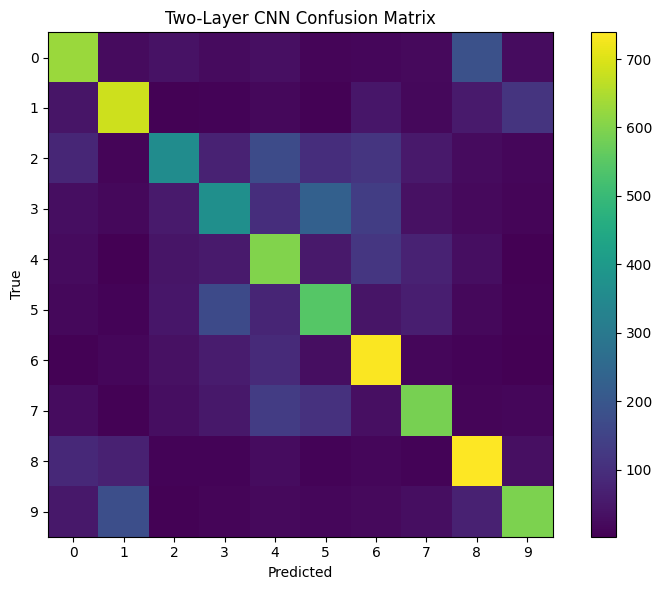

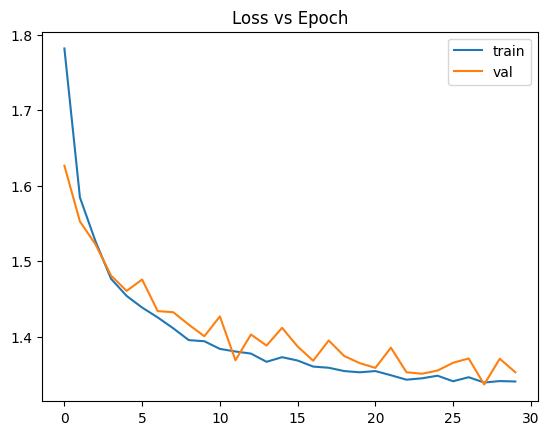

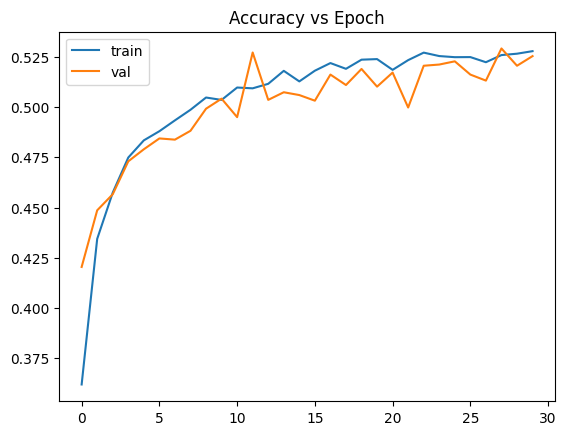

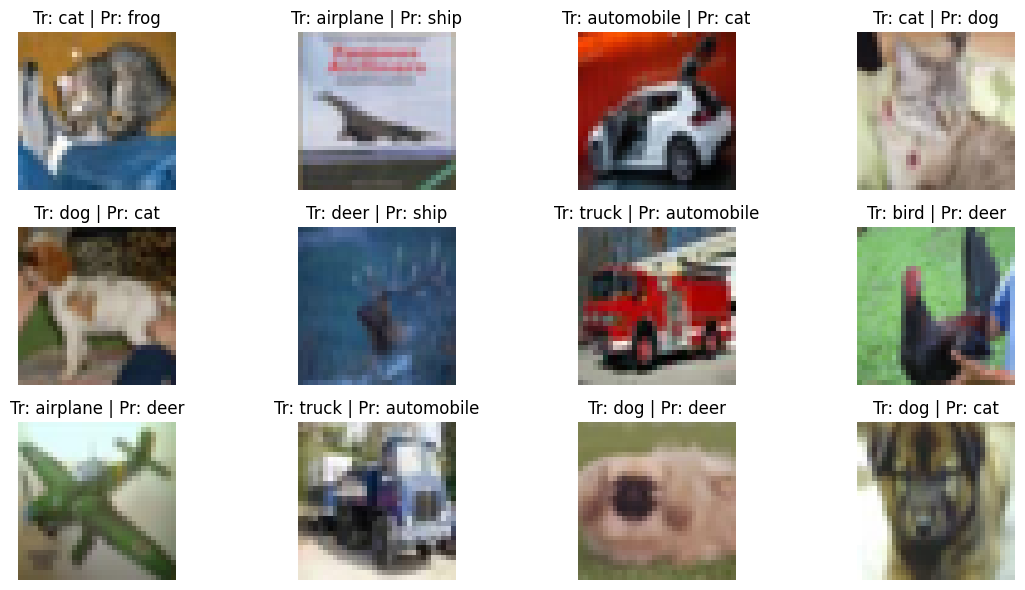

Three layers model
Epoch 01/30 | Train 1.5722/43.82% | Val 1.4237/48.20%
Epoch 02/30 | Train 1.3008/54.22% | Val 1.2836/55.34%
Epoch 03/30 | Train 1.1929/58.08% | Val 1.2442/56.18%
Epoch 04/30 | Train 1.1355/60.46% | Val 1.1934/58.14%
Epoch 05/30 | Train 1.1005/61.76% | Val 1.1109/61.84%
Epoch 06/30 | Train 1.0755/62.67% | Val 1.1340/60.14%
Epoch 07/30 | Train 1.0512/63.72% | Val 1.0681/63.32%
Epoch 08/30 | Train 1.0322/64.12% | Val 1.0784/61.72%
Epoch 09/30 | Train 1.0164/64.80% | Val 1.0767/62.10%
Epoch 10/30 | Train 1.0059/65.14% | Val 1.0359/63.16%
Epoch 11/30 | Train 0.9926/65.65% | Val 1.1579/60.06%
Epoch 12/30 | Train 0.9882/65.80% | Val 1.0329/64.34%
Epoch 13/30 | Train 0.9737/66.45% | Val 1.0580/62.24%
Epoch 14/30 | Train 0.9672/66.72% | Val 1.0343/63.46%
Epoch 15/30 | Train 0.9636/66.86% | Val 0.9760/65.64%
Epoch 16/30 | Train 0.9557/67.05% | Val 1.0418/63.88%
Epoch 17/30 | Train 0.9524/67.15% | Val 0.9915/65.24%
Epoch 18/30 | Train 0.9494/67.19% | Val 1.0252/64.36%
Epoch 19/

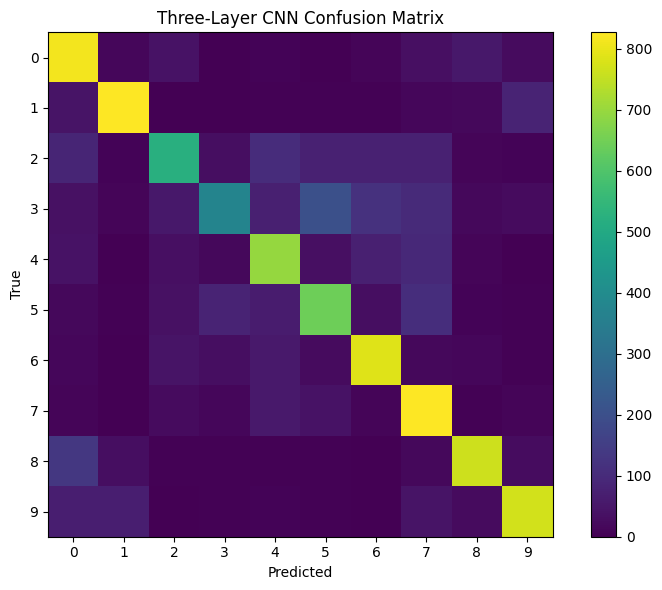

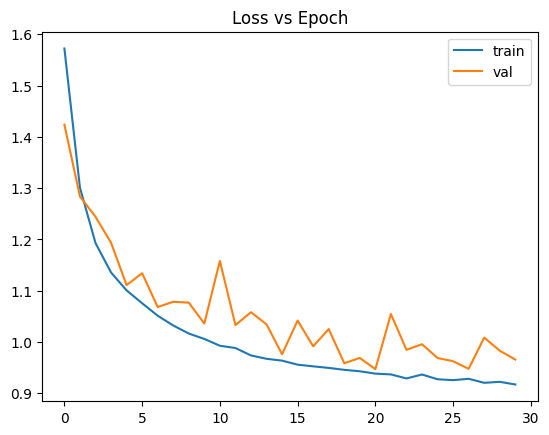

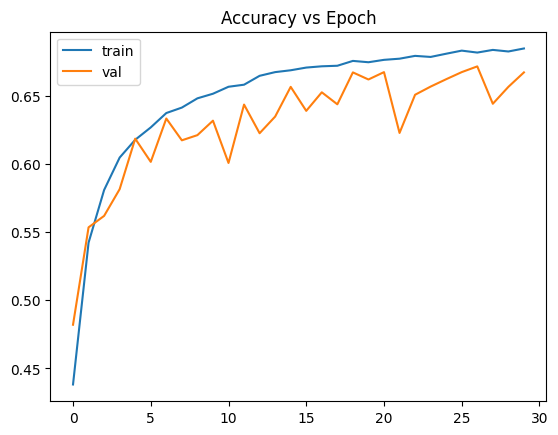

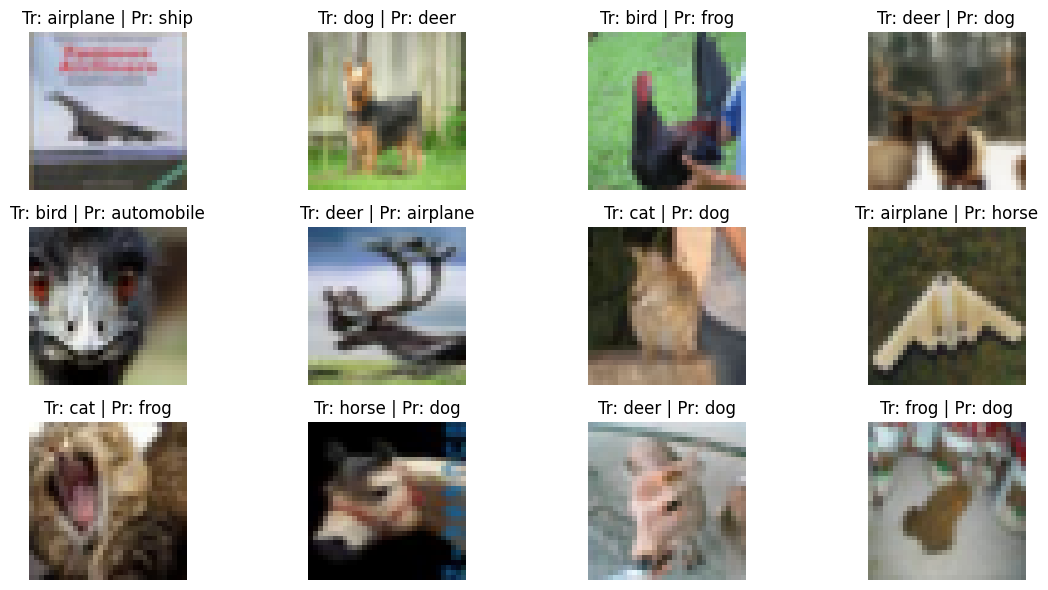

In [9]:
print("Two Layers Model")

num_epochs = 30
train_hist, val_hist = [], []

for epoch in range(1, num_epochs + 1):
  tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
  va_loss, va_acc = evaluate(model, val_loader, criterion, device)
  train_hist.append((tr_loss, tr_acc))
  val_hist.append((va_loss, va_acc))
  if scheduler is not None:
    scheduler.step()
  print(f'Epoch {epoch:02d}/{num_epochs} | Train {tr_loss:.4f}/{100*tr_acc:.2f}% | Val {va_loss:.4f}/{100*va_acc:.2f}%')

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test | loss {test_loss:.4f} acc {100*test_acc:.2f}%")

preds, labels = get_preds_and_labels(model, test_loader, device)
cm = confusion_matrix(labels, preds)
ConfusionMatrix(cm, title="Two-Layer CNN Confusion Matrix")


train_losses = [x[0] for x in train_hist]
train_accs   = [x[1] for x in train_hist]
val_losses   = [x[0] for x in val_hist]
val_accs     = [x[1] for x in val_hist]

plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="val")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

FailureCases(model, test_loader, device, maxImages=12)

model = MyThreeLayerCNN(in_channels, num_classes, channel1=16, channel2=32, channel3=64, use_bn=True).to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

print("Three layers model")
epochs = 30
train_hist, val_hist = [], []

for epoch in range(1, num_epochs + 1):
  tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
  va_loss, va_acc = evaluate(model, val_loader, criterion, device)
  train_hist.append((tr_loss, tr_acc))
  val_hist.append((va_loss, va_acc))
  if scheduler is not None:
    scheduler.step()
  print(f"Epoch {epoch:02d}/{num_epochs} | "f"Train {tr_loss:.4f}/{100*tr_acc:.2f}% | "f"Val {va_loss:.4f}/{100*va_acc:.2f}%")


test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test | loss {test_loss:.4f} acc {100*test_acc:.2f}%")

preds, labels = get_preds_and_labels(model, test_loader, device)
cm = confusion_matrix(labels, preds)
ConfusionMatrix(cm, title="Three-Layer CNN Confusion Matrix")

train_losses = [x[0] for x in train_hist]
train_accs   = [x[1] for x in train_hist]
val_losses   = [x[0] for x in val_hist]
val_accs     = [x[1] for x in val_hist]

plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="val")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

FailureCases(model, test_loader, device, maxImages=12)
